In [1]:
import os
import kagglehub

os.environ["KAGGLE_USERNAME"] = "maria303"
os.environ["KAGGLE_KEY"] = "3e509e67e40b697ccdd34ecf8762dc0b"

# Скачиваем ваш личный датасет
# Формат: kagglehub.dataset_download('username/dataset-name')
your_dataset_path = kagglehub.dataset_download('maria303/dl-lab-2-stuff-detection')

print('Dataset downloaded to:', your_dataset_path)

# Теперь можно посмотреть, что внутри
print('Files in dataset:', os.listdir(your_dataset_path))

100%|██████████| 3.73G/3.73G [00:20<00:00, 191MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/maria303/dl-lab-2-stuff-detection/versions/1
Files in dataset: ['sample_sub.csv', 'test_images', 'yolo_dataset', 'data.yaml']


In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

dl_lab_2_stuff_detection_path = kagglehub.competition_download('dl-lab-2-stuff-detection')

#packagemanager_pm_110859939_at_03_01_2026_13_55_34_path = kagglehub.notebook_output_download('packagemanager/pm-110859939-at-03-01-2026-13-55-34')

print('Data source import complete.')


100%|██████████| 3.24G/3.24G [00:21<00:00, 164MB/s]

Extracting files...


Data source import complete.


In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.7 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo11m.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
import os
import shutil
from sklearn.model_selection import train_test_split
import torch
from pathlib import Path
from ultralytics import YOLO

# Автоматическое определение устройства
device = 0 if torch.cuda.is_available() else 'cpu'
print(f"Использую device: {device}")

# Корневой путь к датасету (исправлено для Colab)
dataset_root = Path("/root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection")

# Пути к данным (исправлено с учетом структуры)
source_images_dir = dataset_root / "yolo_dataset" / "yolo_dataset" / "train" / "images"
source_labels_dir = dataset_root / "yolo_dataset" / "yolo_dataset" / "train" / "labels"

# Пути для нового разбиения (исправлено для Colab)
working_root = Path("/content/split_dataset")
train_img_dir = working_root / "train" / "images"
train_lbl_dir = working_root / "train" / "labels"
val_img_dir = working_root / "val" / "images"
val_lbl_dir = working_root / "val" / "labels"

# Создаем папки
for dir_path in [train_img_dir, train_lbl_dir, val_img_dir, val_lbl_dir]:
    dir_path.mkdir(parents=True, exist_ok=True)

# Получаем все изображения
image_files = list(source_images_dir.glob("*.jpg")) + list(source_images_dir.glob("*.png"))
print(f"Найдено изображений: {len(image_files)}")

if len(image_files) == 0:
    raise ValueError("Нет изображений для обработки. Проверьте пути к датасету.")

has_employee = []
image_paths = []

for img_path in image_files:
    lbl_path = source_labels_dir / f"{img_path.stem}.txt"

    has_emp = 0
    if lbl_path.exists():
        with open(lbl_path, 'r') as f:
            for line in f:
                if line.strip():
                    cls = int(line.strip().split()[0])
                    if cls == 1:
                        has_emp = 1
                        break

    has_employee.append(has_emp)
    image_paths.append(img_path)

total_images = len(has_employee)
employees_count = sum(has_employee)
print(f"Изображений с сотрудниками: {employees_count} ({employees_count/total_images*100:.1f}%)")
print(f"Изображений без сотрудников: {total_images - employees_count}")

# Стратифицированное разбиение
train_imgs, val_imgs, train_has, val_has = train_test_split(
    image_paths, has_employee, test_size=0.2, stratify=has_employee, random_state=42
)

print(f"Train: {len(train_imgs)} изображений, с сотрудниками: {sum(train_has)} ({sum(train_has)/len(train_has)*100:.1f}%)")
print(f"Val:   {len(val_imgs)} изображений, с сотрудниками: {sum(val_has)} ({sum(val_has)/len(val_has)*100:.1f}%)")

# Копируем файлы
def copy_split(img_paths, target_img_dir, target_lbl_dir):
    for img_path in img_paths:
        lbl_path = source_labels_dir / f"{img_path.stem}.txt"
        shutil.copy2(img_path, target_img_dir / img_path.name)
        if lbl_path.exists():
            shutil.copy2(lbl_path, target_lbl_dir / lbl_path.name)

copy_split(train_imgs, train_img_dir, train_lbl_dir)
copy_split(val_imgs, val_img_dir, val_lbl_dir)

# Создаем data.yaml
yaml_content = f"""path: {working_root}
train: train
val: val

nc: 2
names: ['visitor', 'employee']
"""

yaml_path = working_root / "data.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"Датасет создан в: {working_root}")
print(f"data.yaml: {yaml_path}")

# Проверка распределения
def check_distribution(img_dir, lbl_dir, name):
    images = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
    employees = 0
    for img in images:
        lbl = lbl_dir / f"{img.stem}.txt"
        if lbl.exists():
            with open(lbl, 'r') as f:
                for line in f:
                    if line.strip() and int(line.strip().split()[0]) == 1:
                        employees += 1
                        break
    print(f"{name}: {len(images)} изображений, с сотрудниками: {employees} ({employees/len(images)*100:.1f}%)")


check_distribution(train_img_dir, train_lbl_dir, "TRAIN")
check_distribution(val_img_dir, val_lbl_dir, "VAL")

Использую device: 0
Найдено изображений: 3908
Изображений с сотрудниками: 3089 (79.0%)
Изображений без сотрудников: 819
Train: 3126 изображений, с сотрудниками: 2471 (79.0%)
Val:   782 изображений, с сотрудниками: 618 (79.0%)
Датасет создан в: /content/split_dataset
data.yaml: /content/split_dataset/data.yaml
TRAIN: 3126 изображений, с сотрудниками: 2471 (79.0%)
VAL: 782 изображений, с сотрудниками: 618 (79.0%)


**Аугментация**

In [6]:
import albumentations as A
import cv2
import numpy as np

train_transform = A.Compose([
    #случайное образание
    A.HorizontalFlip(p=0.5),

    A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.1, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.Perspective(scale=(0.05, 0.1), p=0.3),
    A.GaussNoise(var_limit=(10.0, 30.0), p=0.1),
    A.Rotate(limit=30, p=0.35, border_mode=cv2.BORDER_CONSTANT, value=0)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

/tmp/ipykernel_464/1037254946.py:12: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 30.0), p=0.1),
/tmp/ipykernel_464/1037254946.py:13: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  A.Rotate(limit=30, p=0.35, border_mode=cv2.BORDER_CONSTANT, value=0)


## Процесс обучения очень простой

In [7]:
results = model.train(data=r"/content/split_dataset/data.yaml", epochs=140, imgsz=840,
                      name='lab2',
                      project='miet',
                      device=device,
                      optimizer='auto',
                      augmentations=train_transform,
                      mixup=0.2,
                      dropout = 0.15,
                      save=True,
                      save_period=5,
                      exist_ok=True

                     )

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, augmentations=Compose([
  HorizontalFlip(p=0.5),
  ColorJitter(p=0.3, brightness=(0.85, 1.15), contrast=(0.85, 1.15), hue=(-0.1, 0.1), saturation=(0.85, 1.15)),
  RandomBrightnessContrast(p=0.5, brightness_by_max=True, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), ensure_safe_range=False),
  Perspective(p=0.3, border_mode=0, fill=0.0, fill_mask=0.0, fit_output=False, interpolation=1, keep_size=True, mask_interpolation=0, scale=(0.05, 0.1)),
  GaussNoise(p=0.1, mean_range=(0.0, 0.0), noise_scale_factor=1.0, per_channel=True, std_range=(0.2, 0.44)),
  Rotate(p=0.35, border_mode=0, crop_border=False, fill=0.0, fill_mask=0.0, interpolation=1, limit=(-30.0, 30.0), mask_interpolation=0, rotate_method='largest_box'),
], p=1.0, bbox_params={'format': 'yolo', 'label_fields': ['class_labels'], 'min_area': 0.0, 'min_vis

/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:465: UserWarning: transforms is single transform, but a sequence is expected! Transform will be wrapped into list.
  super().__init__(


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2699.6±2091.1 MB/s, size: 458.0 KB)
val: Scanning /content/split_dataset/val/labels... 782 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 782/782 1.3Kit/s 0.6s
val: New cache created: /content/split_dataset/val/labels.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 106 weight(decay=0.0), 113 weight(decay=0.0005), 112 bias(decay=0.0)
Plotting labels to /content/runs/detect/miet/lab2/labels.jpg... 
Image sizes 864 train, 864 val
Using 8 dataloader workers
Logging results to /content/runs/detect/miet/lab2
Starting training for 140 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/140      14.3G      1.651      1.817       1.53         70        864: 100% ━━━━━━━━━━━━ 196/196 2.8it/s 1:09
                 Class     Imag

/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:465: UserWarning: transforms is single transform, but a sequence is expected! Transform will be wrapped into list.
  super().__init__(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    131/140      14.3G      0.778     0.4581     0.9783         30        864: 100% ━━━━━━━━━━━━ 196/196 4.2it/s 47.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.1it/s 4.1s
                   all        782       4083      0.931      0.893      0.944      0.773

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    132/140      14.3G     0.7854       0.46     0.9866         23        864: 100% ━━━━━━━━━━━━ 196/196 4.3it/s 45.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.1it/s 4.1s
                   all        782       4083      0.932      0.891       0.94       0.77

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    133/140      14.3G     0.7538     0.4428      0.977         26        864: 100% ━━━━━━━━━

Дообучение

In [8]:
best_model = YOLO('/content/runs/detect/miet/lab2/weights/best.pt')

results = best_model.train(
    data=r"/content/split_dataset/data.yaml",
    epochs=45,
    imgsz=720,
    name='lab2_finetune_lr0005',
    project='miet',
    device=device,
    optimizer='auto',
    lr0=0.005,
    warmup_epochs=0,
    augmentations=train_transform,
    patience=10,
    mixup=0.2,
    dropout = 0.15,
    copy_paste=0.25,
    save=True,
    save_period=5,
    exist_ok=True

)




Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, augmentations=Compose([
  HorizontalFlip(p=0.5),
  ColorJitter(p=0.3, brightness=(0.85, 1.15), contrast=(0.85, 1.15), hue=(-0.1, 0.1), saturation=(0.85, 1.15)),
  RandomBrightnessContrast(p=0.5, brightness_by_max=True, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), ensure_safe_range=False),
  Perspective(p=0.3, border_mode=0, fill=0.0, fill_mask=0.0, fit_output=False, interpolation=1, keep_size=True, mask_interpolation=0, scale=(0.05, 0.1)),
  GaussNoise(p=0.1, mean_range=(0.0, 0.0), noise_scale_factor=1.0, per_channel=True, std_range=(0.2, 0.44)),
  Rotate(p=0.35, border_mode=0, crop_border=False, fill=0.0, fill_mask=0.0, interpolation=1, limit=(-30.0, 30.0), mask_interpolation=0, rotate_method='largest_box'),
], p=1.0, bbox_params={'format': 'yolo', 'label_fields': ['class_labels'], 'min_area': 0.0, 'min_vis

/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:465: UserWarning: transforms is single transform, but a sequence is expected! Transform will be wrapped into list.
  super().__init__(


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1150.8±946.2 MB/s, size: 442.7 KB)
val: Scanning /content/split_dataset/val/labels.cache... 782 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 782/782 27.1Mit/s 0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.005' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 106 weight(decay=0.0), 113 weight(decay=0.0005), 112 bias(decay=0.0)
Plotting labels to /content/runs/detect/miet/lab2_finetune_lr0005/labels.jpg... 
Image sizes 736 train, 736 val
Using 8 dataloader workers
Logging results to /content/runs/detect/miet/lab2_finetune_lr0005
Starting training for 45 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/45      10.9G      1.151     0.8185      1.166         70        736: 100% ━━━━━━━━━━━━ 196/196 3.6it/s 54.9s
                 Class     Images  Instances      Box(P 

/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:465: UserWarning: transforms is single transform, but a sequence is expected! Transform will be wrapped into list.
  super().__init__(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      36/45      10.9G     0.8148      0.475     0.9776         26        736: 100% ━━━━━━━━━━━━ 196/196 5.4it/s 36.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.8it/s 3.7s
                   all        782       4083      0.932      0.884      0.938      0.755

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      37/45      10.9G     0.8174     0.4788      0.981         32        736: 100% ━━━━━━━━━━━━ 196/196 5.5it/s 35.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.9it/s 3.6s
                   all        782       4083      0.925       0.88      0.939      0.759

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      38/45      10.9G     0.7985     0.4749     0.9721         31        736: 100% ━━━━━━━━━

In [9]:
from google.colab import files
import os




print("\n Дообучение (lab2_finetune_lr0005):")


finetune_files = [
    ("Лучшая модель", "/content/runs/detect/miet/lab2_finetune_lr0005/weights/best.pt"),
    ("Графики", "/content/runs/detect/miet/lab2_finetune_lr0005/results.png"),
    ("Метрики CSV", "/content/runs/detect/miet/lab2_finetune_lr0005/results.csv"),
    ("Последняя модель", "/content/runs/detect/miet/lab2_finetune_lr0005/weights/last.pt")
]

for name, path in finetune_files:
    if os.path.exists(path):
        print(f"   {name}: скачивается...")
        files.download(path)
    else:
        print(f"   {name}: файл не найден")


print("\n Основное обучение (lab2):")

main_files = [
    ("Лучшая модель", "/content/runs/detect/miet/lab2/weights/best.pt"),
    ("Графики", "/content/runs/detect/miet/lab2/results.png"),
    ("Метрики CSV", "/content/runs/detect/miet/lab2/results.csv"),
    ("Последняя модель", "/content/runs/detect/miet/lab2/weights/last.pt")
]

for name, path in main_files:
    if os.path.exists(path):
        print(f"   {name}: скачивается")
        files.download(path)
    else:
        print(f"   {name}: файл не найден")

print("\n Все файлы скачаны!")


 Дообучение (lab2_finetune_lr0005):
   Лучшая модель: скачивается...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   Графики: скачивается...


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   Последняя модель: скачивается


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Все файлы скачаны!


# Загружаем нашу лучшую модель

In [ ]:
# model = YOLO('/content/runs/detect/miet/lab2/weights/best.pt')

In [10]:

model = YOLO('/content/runs/detect/miet/lab2_finetune_lr0005/weights/best.pt')

In [11]:
results = model.predict(r'/root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/test_images/test_images', save_txt=True, save_conf=True, stream=True,conf=0.25, augment=True,iou=0.75)
for r in results:
    pass


image 1/4454 /root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/test_images/test_images/1.1_00-00-00-000.jpg: 416x736 2 visitors, 263.4ms
image 2/4454 /root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/test_images/test_images/1.1_00-00-12-500.jpg: 416x736 2 visitors, 1 employee, 37.5ms
image 3/4454 /root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/test_images/test_images/1.1_00-00-25-000.jpg: 416x736 2 visitors, 36.9ms
image 4/4454 /root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/test_images/test_images/1.1_00-00-37-500.jpg: 416x736 2 visitors, 36.9ms
image 5/4454 /root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/test_images/test_images/1.1_00-00-50-000.jpg: 416x736 2 visitors, 36.8ms
image 6/4454 /root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/test_images/test_images/1.1_00-01-02-500.jpg: 416x736 2 visitors, 1 employee, 37.7ms
image 7/4454 /root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/test_images/test_i

In [12]:
# Путь к графикам
plots_path = "/content/runs/detect/miet/lab2/results.png"

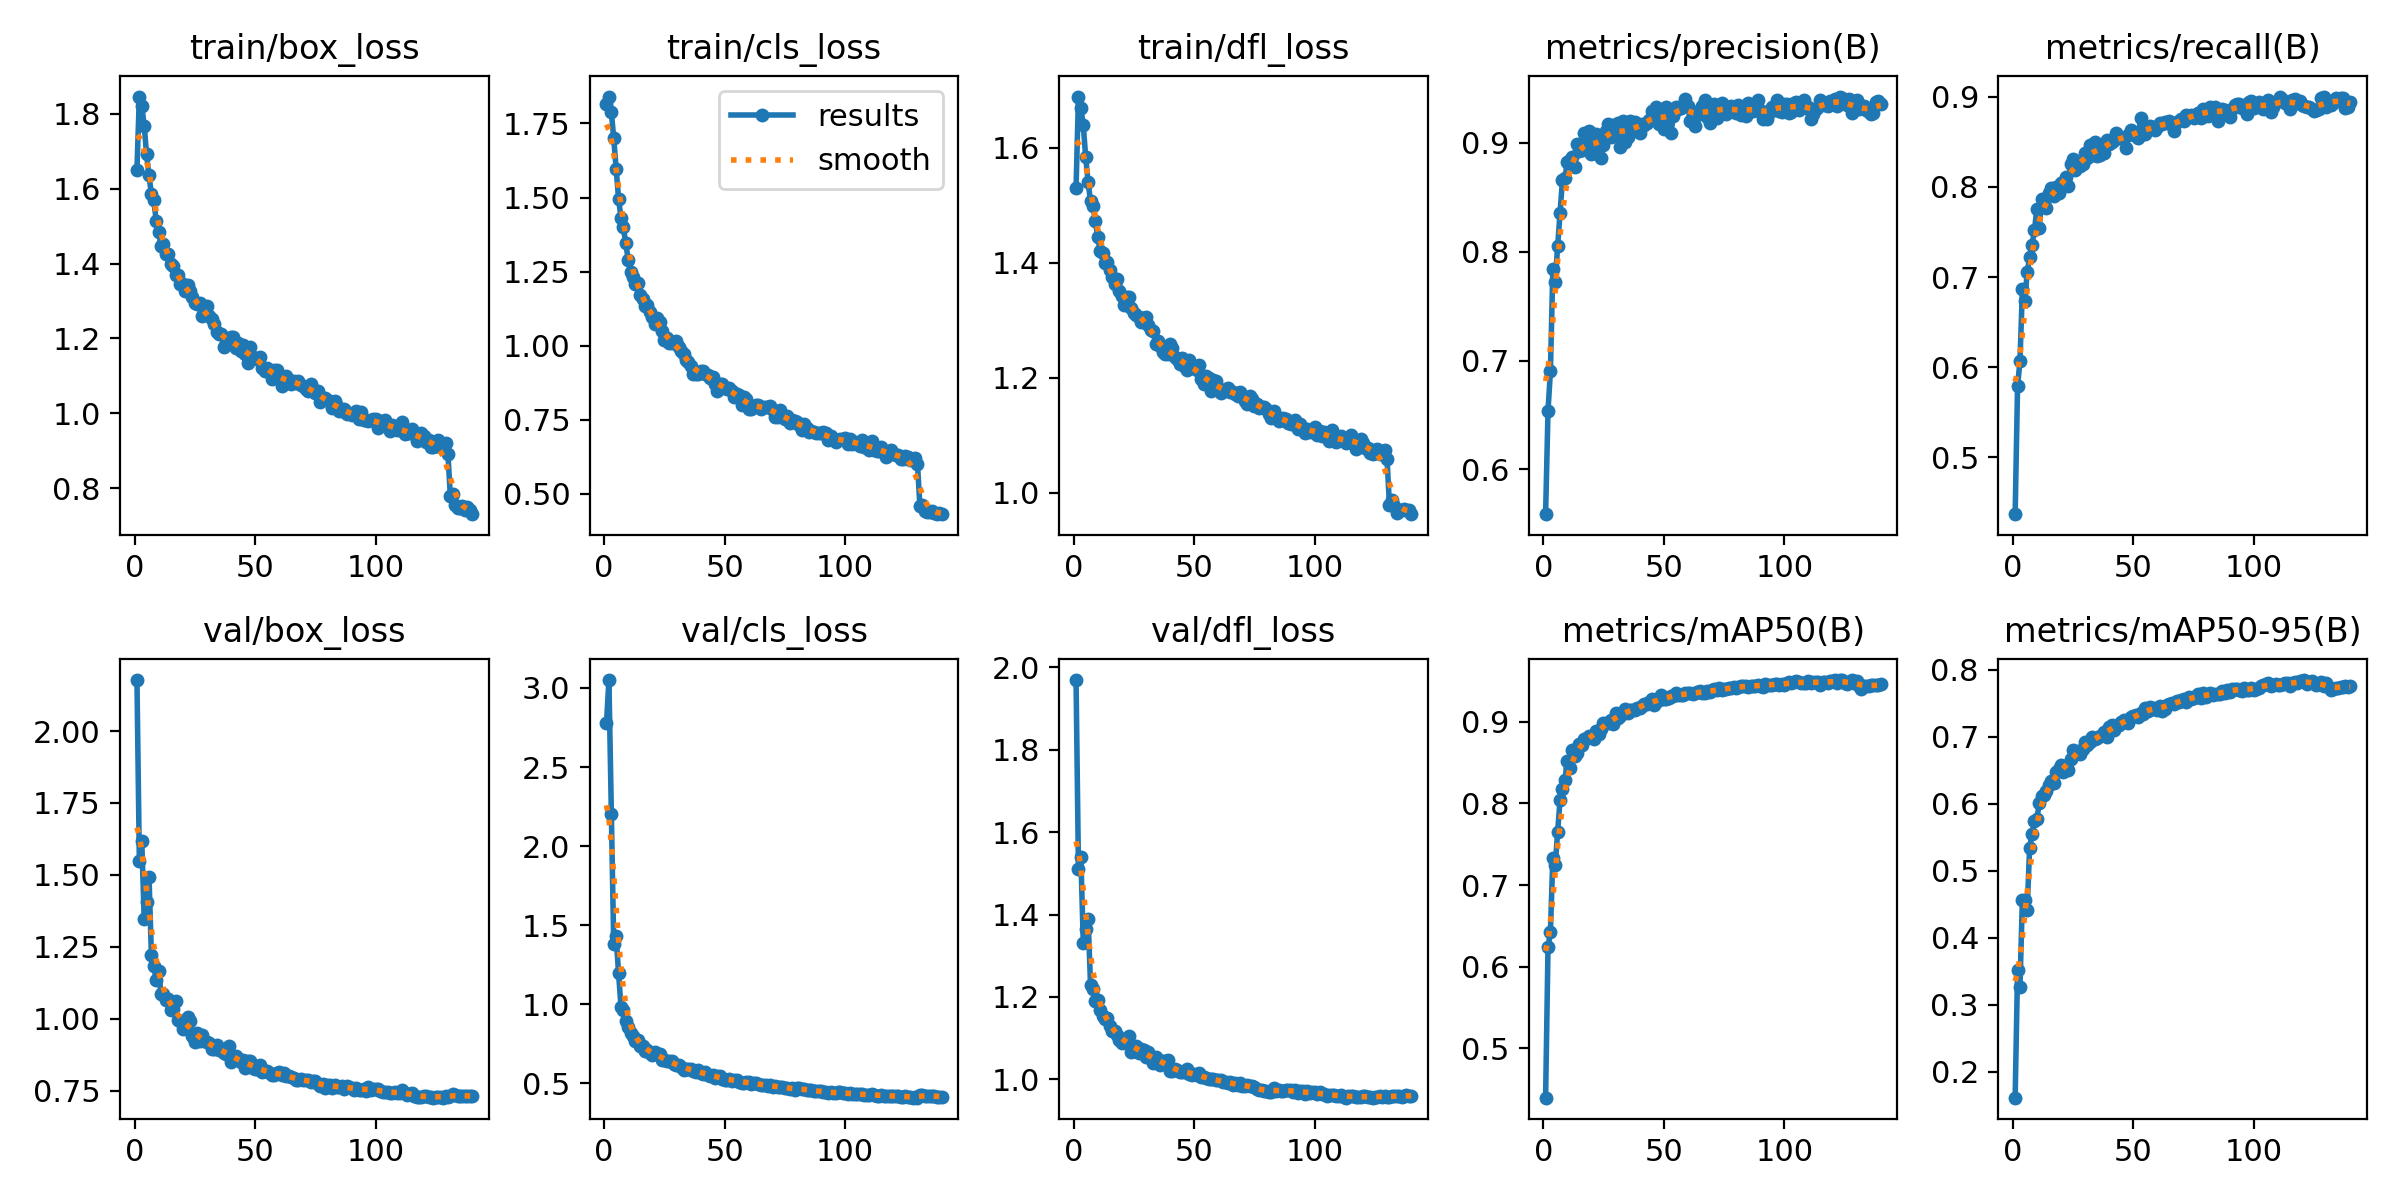

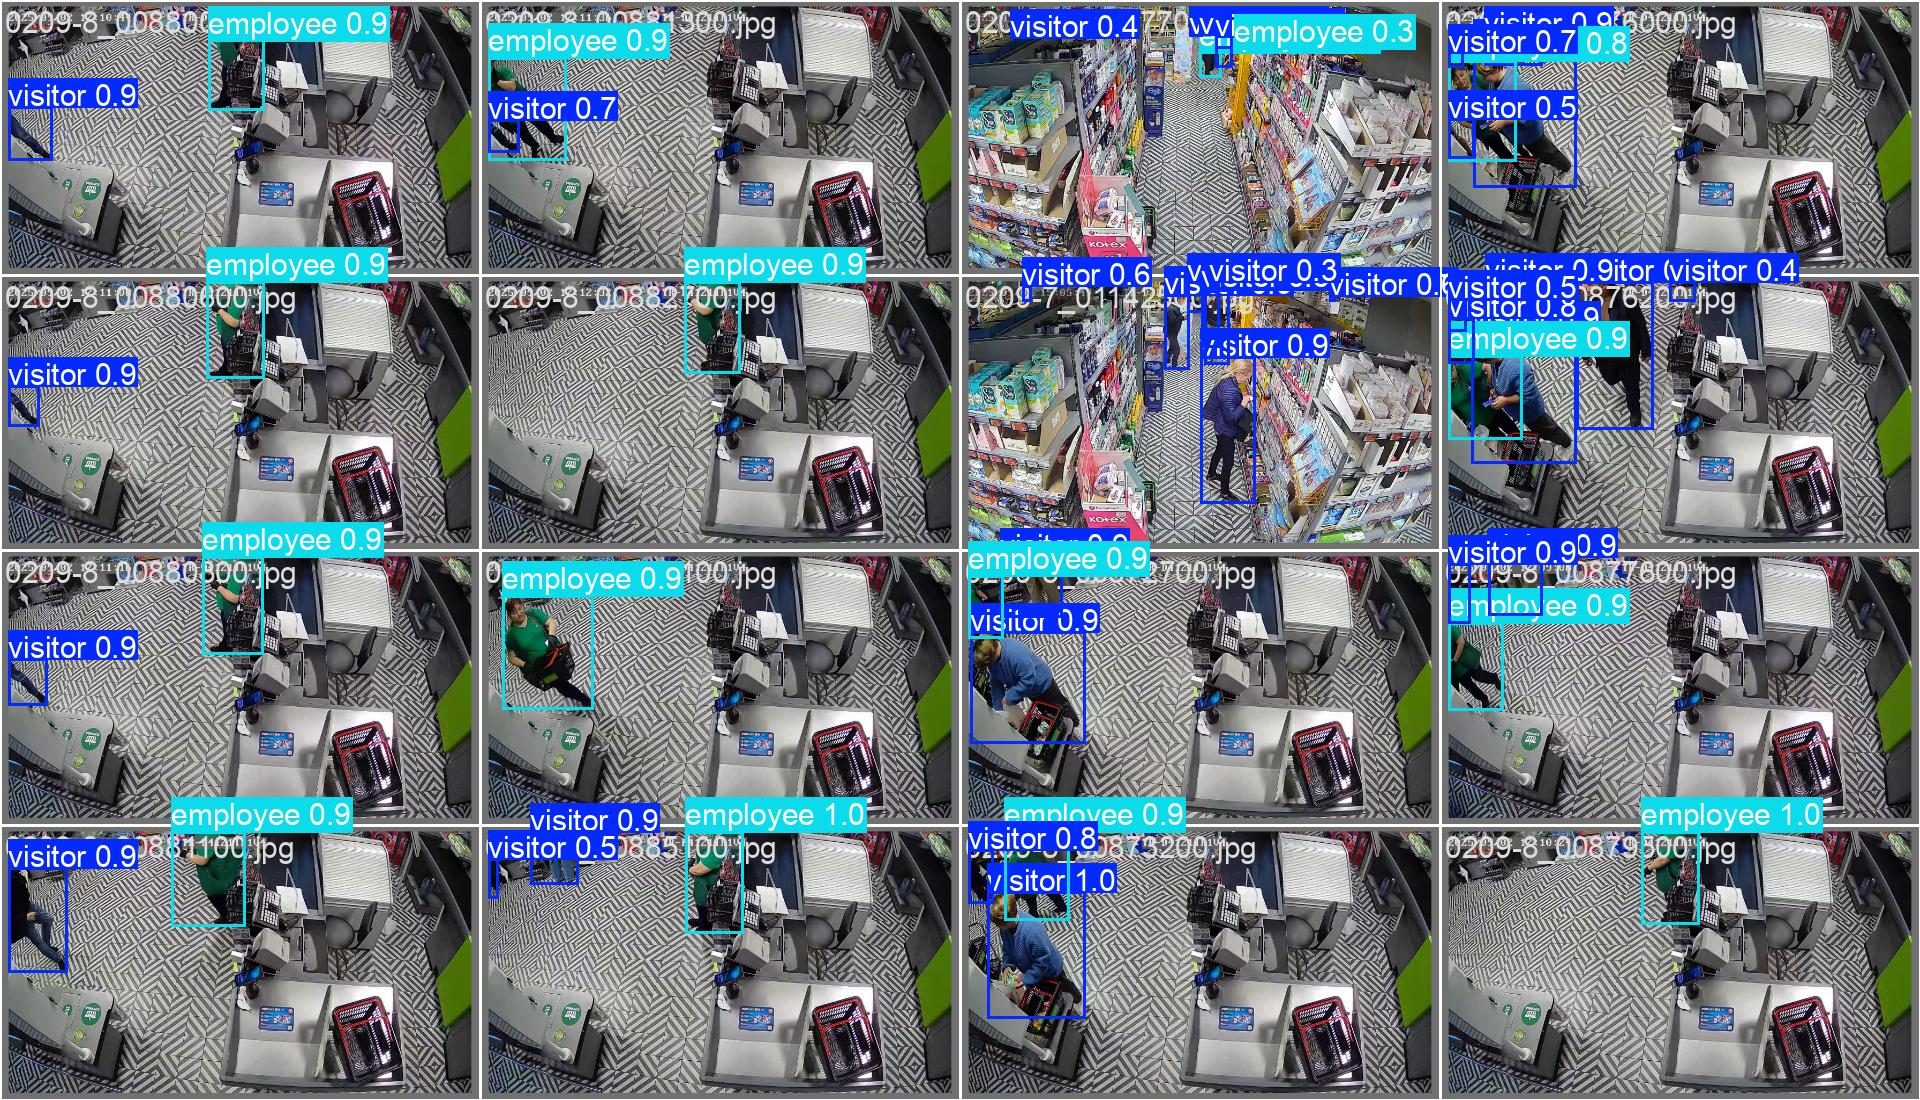

In [13]:
from IPython.display import Image, display
from pathlib import Path

results_dir = "/content/runs/detect/miet/lab2"

# График обучения
if (Path(results_dir) / 'results.png').exists():
    display(Image(filename=str(Path(results_dir) / 'results.png')))

# Примеры предсказаний
if (Path(results_dir) / 'val_batch0_pred.jpg').exists():
    display(Image(filename=str(Path(results_dir) / 'val_batch0_pred.jpg')))

 Проверяем папку: /content/runs/detect/miet/lab2_finetune_lr0005
 График найден: /content/runs/detect/miet/lab2_finetune_lr0005/results.png


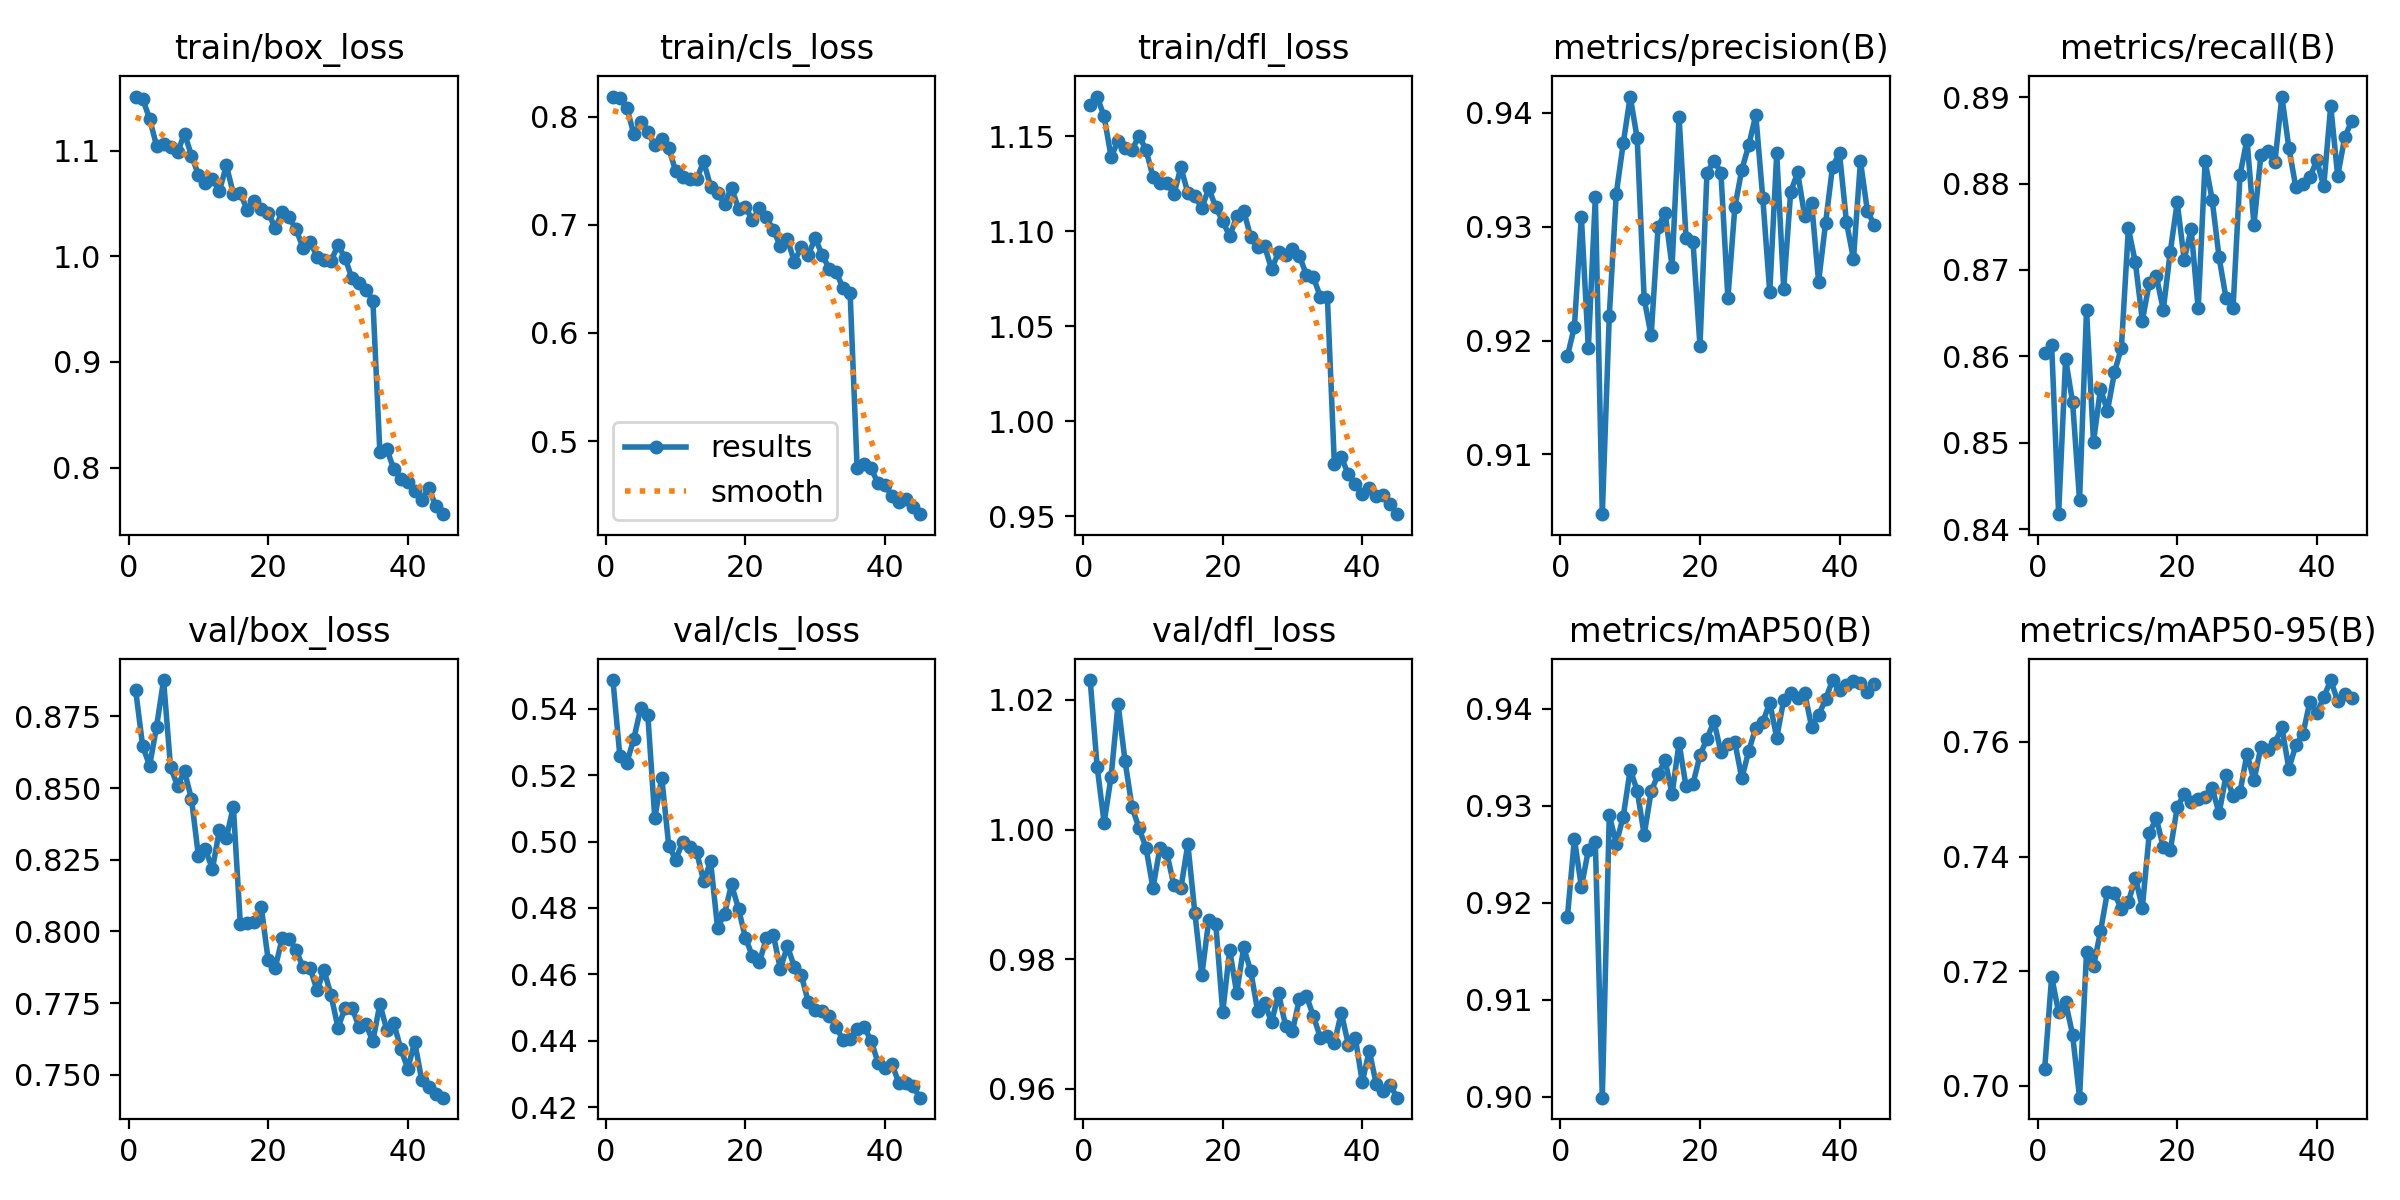


 Примеры предсказаний найдены: /content/runs/detect/miet/lab2_finetune_lr0005/val_batch0_pred.jpg


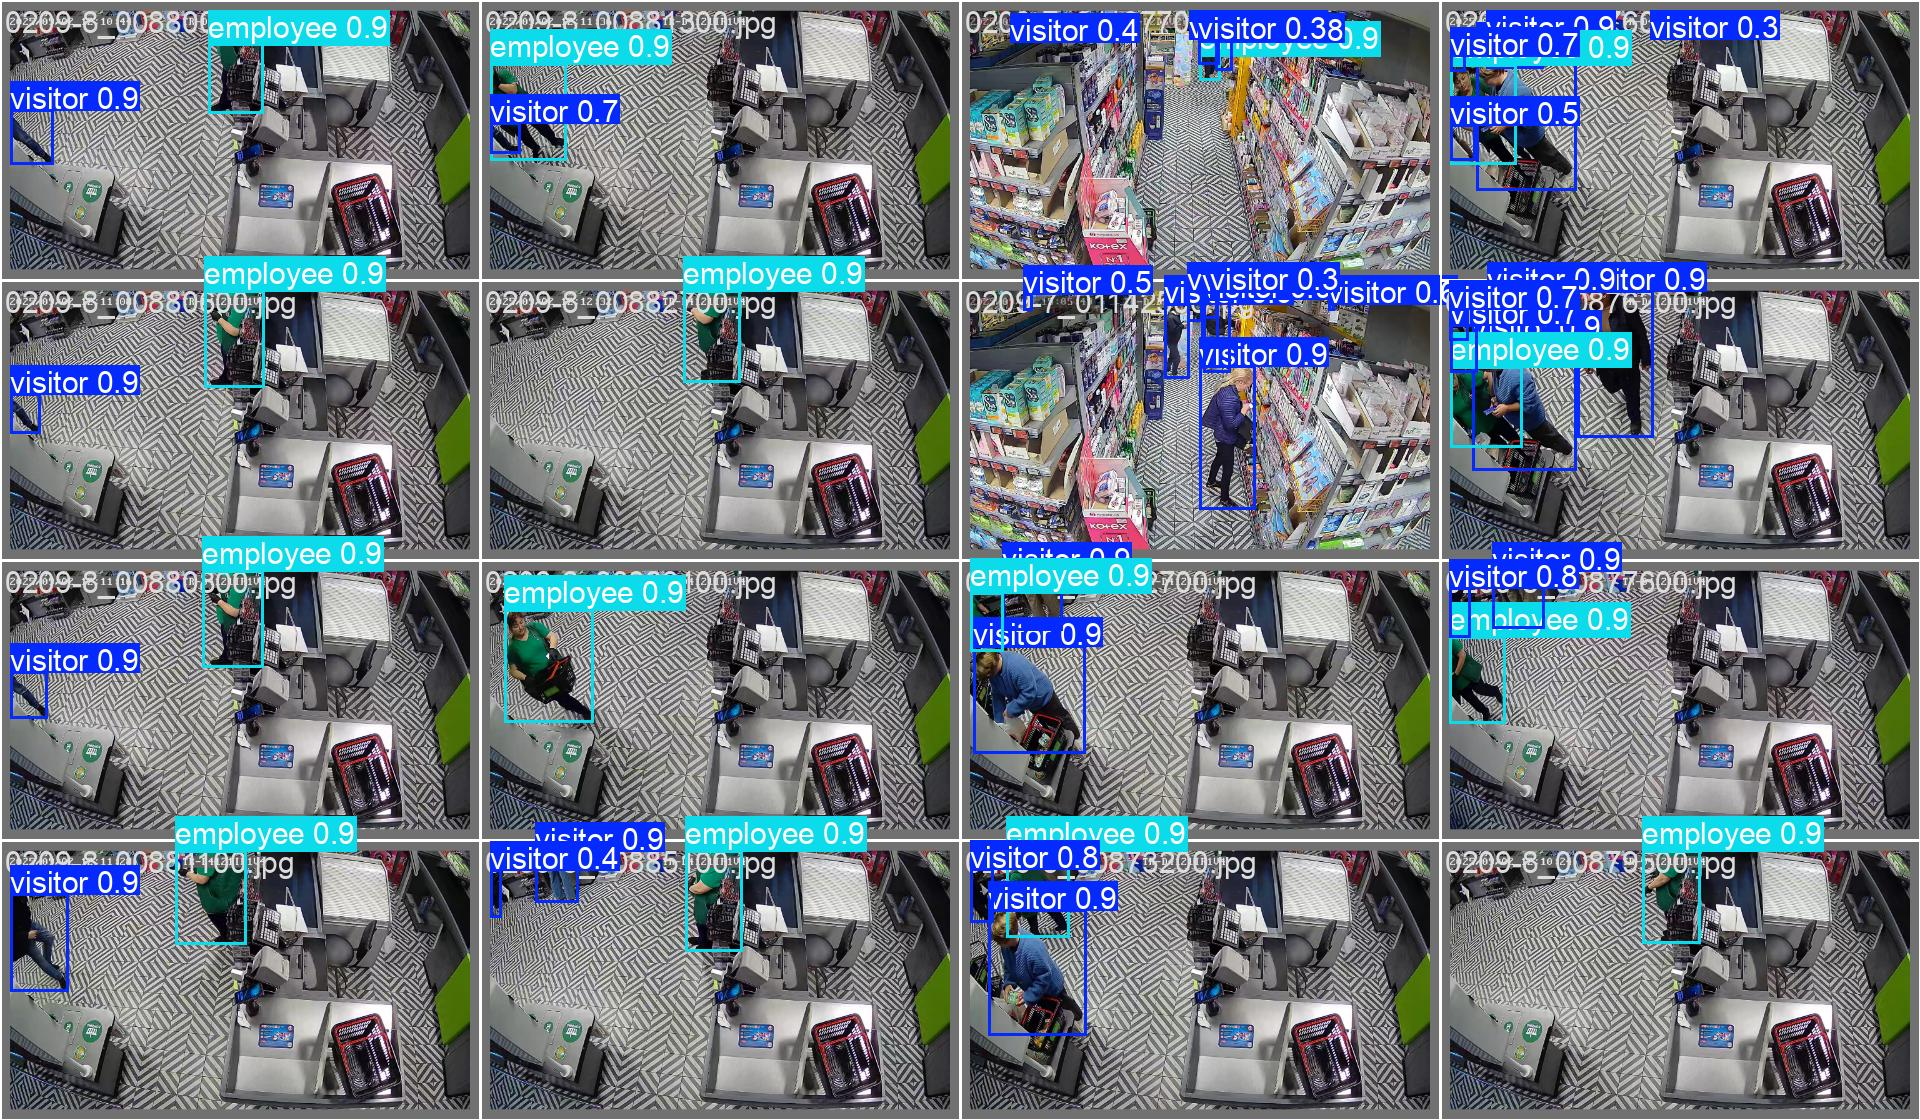

In [14]:
from IPython.display import Image, display
from pathlib import Path

results_dir = "/content/runs/detect/miet/lab2_finetune_lr0005"

print(f" Проверяем папку: {results_dir}")


plots_path = Path(results_dir) / 'results.png'
if plots_path.exists():
    print(f" График найден: {plots_path}")
    display(Image(filename=str(plots_path)))
else:
    print(f" График не найден: {plots_path}")


pred_path = Path(results_dir) / 'val_batch0_pred.jpg'
if pred_path.exists():
    print(f"\n Примеры предсказаний найдены: {pred_path}")
    display(Image(filename=str(pred_path)))
else:
    print(f"\n Примеры предсказаний не найдены: {pred_path}")

# Собираем итоговое предсказание

In [15]:
from pathlib import Path
import json
import pandas as pd


def build_submission_from_solution_order(
    solution_csv: str,
    preds_dir: str,
    output_csv: str = "submission.csv",
    image_col: str = "image_name",
    boxes_col: str = "boxes",
    row_id_col: str = "id",
    require_score: bool = True,
    clamp_score: bool = True,
    keep_only_class: int | None = None,  # например 1, если нужны только строки класса 1; None = все классы
) -> None:
    """
    Builds submission.csv in EXACTLY the same image_name order as solution.csv.

    - Reads solution_csv, takes image_name column order as ground truth order.
    - For each image_name, looks for preds_dir/<stem>.txt
      where stem is Path(image_name).stem
    - If missing -> boxes=[]
    - Prediction txt lines: class xc yc w h score
    - Output boxes: JSON [[xc,yc,w,h,score], ...]
    """
    sol_path = Path(solution_csv)
    pdir = Path(preds_dir)

    if not sol_path.exists():
        raise FileNotFoundError(f"solution_csv not found: {sol_path}")
    if not pdir.exists() or not pdir.is_dir():
        raise FileNotFoundError(f"preds_dir not found or not a dir: {pdir}")

    sol = pd.read_csv(sol_path)
    if image_col not in sol.columns:
        raise ValueError(f"solution.csv must contain column '{image_col}'")

    # Keep original order from solution
    image_names = sol[image_col].astype(str).tolist()

    rows = []
    for idx, image_name in enumerate(image_names):
        stem = Path(image_name).stem
        pred_file = pdir / f"{stem}.txt"

        boxes = []
        if pred_file.exists():
            content = pred_file.read_text(encoding="utf-8", errors="replace").strip()
            if content:
                for ln in content.splitlines():
                    ln = ln.strip()
                    if not ln:
                        continue
                    parts = ln.split()
                    if require_score and len(parts) < 6:
                        continue
                    if len(parts) < 5:
                        continue

                    try:
                        cls = int(float(parts[0]))
                        if keep_only_class is not None and cls != keep_only_class:
                            continue

                        xc = float(parts[1])
                        yc = float(parts[2])
                        w = float(parts[3])
                        h = float(parts[4])
                        sc = float(parts[5]) if len(parts) >= 6 else 1.0
                    except ValueError:
                        continue

                    if clamp_score:
                        sc = 0.0 if sc < 0.0 else (1.0 if sc > 1.0 else sc)

                    boxes.append([xc, yc, w, h, sc])

        rows.append(
            {
                row_id_col: idx,
                image_col: image_name,  # EXACT match
                boxes_col: json.dumps(boxes, separators=(",", ":")),
            }
        )

    sub = pd.DataFrame(rows, columns=[row_id_col, image_col, boxes_col])
    sub.to_csv(output_csv, index=False)
    print(f"Saved: {output_csv} ({len(sub)} rows). Missing preds filled with [] in solution order.")


# пример запуска:


In [19]:
build_submission_from_solution_order(
    solution_csv = "/root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/sample_sub.csv",
    preds_dir = "/content/runs/detect/predict/labels",
    output_csv="submission.csv",
    keep_only_class=1,  # если нужно брать только класс 1; если нет — поставь None
)

Saved: submission.csv (4454 rows). Missing preds filled with [] in solution order.


In [20]:
from google.colab import files

files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Data source import complete.
